# 가설 2. 이용 목적별 저만족 비율 차이 분석

- 이용 목적에 따라 저만족 비율 및 심각한 저만족 비율의 편차가 존재할 것이다.

## 라이브러리 로드

In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import ConnectionPatch
from scipy.stats import chi2_contingency

sns.set_style("whitegrid")

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

## 저만족 관련 파생 변수 생성

In [ ]:
# 설문 A와 B를 통합한 마스터 테이블 로드
df = pd.read_excel("../data/master_table.xlsx")

In [11]:
score_cols = [col for col in df.columns if col.startswith('sat')]

df['low_sat_flag'] = (df[score_cols] <= 3).any(axis=1)
df['serious_sat_flag'] = (df[score_cols] <= 2).any(axis=1)

## 전체 비율 계산

In [12]:
low_sat = df['low_sat_flag'].mean()
serious_sat = df['serious_sat_flag'].mean()

low_sat_only = low_sat - serious_sat
normal_sat = 1 - low_sat

print(f"저만족 비율: {low_sat:.3f}")
print(f"심각 저만족 비율: {serious_sat:.3f}")

저만족 비율: 0.377
심각 저만족 비율: 0.120


## 세그먼트별 비율 계산

In [14]:
segment_stats = df.groupby('cat_01')[[
    'low_sat_flag',
    'serious_sat_flag'
]].mean()

display(segment_stats)

,low_sat_flag,serious_sat_flag
cat_01,,
type_A,0.358750,0.111250
type_B,0.400000,0.100000
type_C,0.442857,0.171429
type_D,0.633333,0.300000


## 카이제곱 검정

In [16]:
contingency_table = pd.crosstab(
    df['cat_01'],
    df['low_sat_flag']
)

chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square statistic: {chi2:.3f}")
print(f"p-value: {p:.5f}")

Chi-square statistic: 11.045
p-value: 0.01148


## 전체 응답자 중 잠재적 불만자 비율

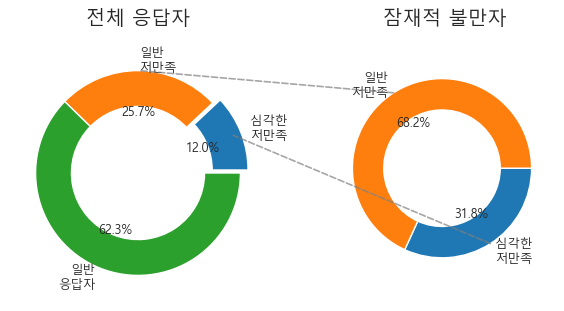

In [20]:
fig = plt.figure()

plt.figtext(0.25, 0.85, '전체 응답자', ha='center', fontsize=14)
plt.figtext(0.73, 0.85, '잠재적 불만자', ha='center', fontsize=14)

# 전체 응답자
ax1 = fig.add_axes([0.05, 0.18, 0.4, 0.72])
wedges1, texts1, autotexts1 = ax1.pie(
    [serious_sat, low_sat_only, normal_sat],
    labels=['심각한\n저만족', '일반\n저만족', '일반\n응답자'],
    autopct='%1.1f%%',
    wedgeprops=dict(width=0.35),
    explode=[0.08, 0, 0]
)

# 저만족 내부 구조
ax2 = fig.add_axes([0.55, 0.30, 0.35, 0.50])
wedges2, texts2, autotexts2 = ax2.pie(
    [serious_sat, low_sat_only],
    labels=['심각한\n저만족', '일반\n저만족'],
    autopct='%1.1f%%',
    wedgeprops=dict(width=0.35),
    startangle=wedges1[0].theta1,
    counterclock=False
)

outer_r = 1.0

for (w1, w2) in zip(wedges1[:2], wedges2):

    theta = (w1.theta1 + w1.theta2) / 2
    x1, y1 = outer_r * np.cos(np.deg2rad(theta)), outer_r * np.sin(np.deg2rad(theta))

    theta_b = (w2.theta1 + w2.theta2) / 2
    x2, y2 = outer_r * np.cos(np.deg2rad(theta_b)), outer_r * np.sin(np.deg2rad(theta_b))

    con = ConnectionPatch(
        xyA=(x2, y2),
        xyB=(x1, y1),
        axesA=ax2,
        axesB=ax1,
        coordsA="data",
        coordsB="data",
        color="gray",
        linestyle="--",
        linewidth=1.2,
        alpha=0.7
    )

    fig.add_artist(con)

for t in texts1 + autotexts1:
    t.set_fontsize(9)

for t in texts2 + autotexts2:
    t.set_fontsize(9)

plt.show()

## 세그먼트별 저만족 비율

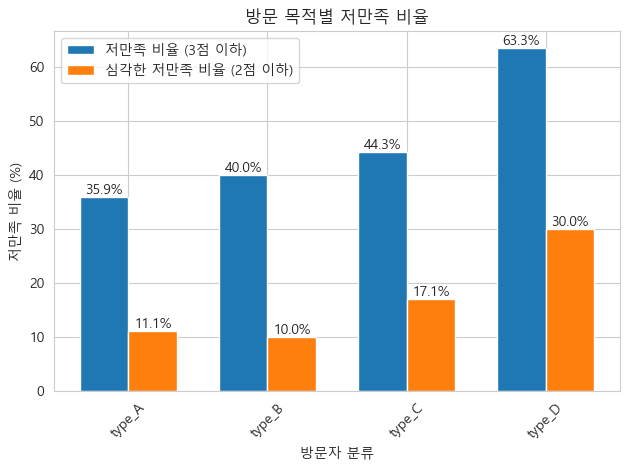

In [21]:
x = np.arange(len(segment_stats.index))
width = 0.35

low_vals = segment_stats['low_sat_flag'] * 100
serious_vals = segment_stats['serious_sat_flag'] * 100

plt.figure()

bars1 = plt.bar(x - width/2, low_vals, width, label='저만족 비율 (3점 이하)')
bars2 = plt.bar(x + width/2, serious_vals, width, label='심각한 저만족 비율 (2점 이하)')

plt.title('방문 목적별 저만족 비율')
plt.xlabel('방문자 분류')
plt.ylabel('저만족 비율 (%)')

plt.xticks(x, segment_stats.index, rotation=45)
plt.legend()

for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'{height:.1f}%', ha='center', va='bottom')

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'{height:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

## 결론

- 전체 응답자를 기준으로 보면, 저만족 경험 비율은 약 37%, 심각한 저만족 경험 비율은 약 12%로 나타났다.
- 세그먼트별로 나누어 보면 집단 간 차이가 확인되었다.응답 비중이 가장 낮은(3%) type_D에서는 저만족 비율이 63%로 과반수를 넘었고, 응답 비중이 가장 높은(80%) type_A 그룹에서는 저만족 비율이 약 34%로 가장 낮게 나타나 비교적 안정적인 만족도 수준을 보였다.
- 이용 목적 세그먼트와 저만족 경험 간의 관계를 확인하기 위해 카이제곱 검정을 수행한 결과, 세그먼트 간 차이는 통계적으로 유의한 것으로 나타났다(p < 0.05).
- 즉, 이용 목적에 따라 저만족 및 심각 저만족 비율에 차이가 존재한다는 가설은 데이터 분석 결과 지지되었다.